[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/quarcs-lab/ds4bolivia/blob/master/notebooks/esda_heterogeneity.ipynb)

# Spatial Heterogeneity (GWR & MGWR)

An interactive tutorial exploring how the relationship between nighttime lights and regional development varies across Bolivia's 339 municipalities. This notebook covers Geographically Weighted Regression (GWR) and Multiscale GWR (MGWR) to detect spatially varying coefficients.

## Setup

In [1]:
# Install packages not included in Google Colab's default environment.
# When running locally with UV, these are already installed and this cell is harmless.
!pip install contextily libpysal mgwr -q

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import contextily as cx

from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW

import warnings
warnings.filterwarnings('ignore')

## Import data

In [3]:
dataURL = 'https://github.com/quarcs-lab/project2021o-notebook/raw/main/map_and_data.geojson'
gdf = gpd.read_file(dataURL)
gdf.head(3)

,asdf_id,shapeName,COORD_X,COORD_Y,poly_id,mun,mun_id,dep,dep_id,dep_mun,...,co2018,co2019,co2020,tr400_co2015,tr400_co2016,tr400_co2017,tr400_co2018,tr400_co2019,tr400_co2020,geometry
0,0,Esmeralda,-68.086369,-18.945744,178,Esmeralda,40505,Oruro,5,Oruro-Esmeralda,...,406.84192,408.98264,410.99747,400.56021,402.63989,404.73074,406.83206,408.94409,411.06708,"MULTIPOLYGON (((-68.26703 -18.81616, -68.23937..."
1,1,Santuario de Quillacas,-66.813557,-19.318918,169,Quillacas,40202,Oruro,5,Oruro-Quillacas,...,406.64880,408.32587,410.74161,399.42441,401.71268,404.01230,406.32236,408.64389,410.97791,"MULTIPOLYGON (((-66.50208 -19.3599, -66.56355 ..."
2,2,Pampa Aullagas,-67.165981,-19.231799,185,Pampa Aullagas,40802,Oruro,5,Oruro-Pampa Aullagas,...,405.79669,409.45132,410.87640,398.97784,401.38046,403.79791,406.23071,408.67877,411.14096,"MULTIPOLYGON (((-67.01372 -19.1954, -67.0152 -..."


In [4]:
dataDefinitions = pd.read_csv('https://raw.githubusercontent.com/quarcs-lab/project2021o-notebook/main/dataDefinitions.csv')
data_dict = dict(zip(dataDefinitions['Variable'], dataDefinitions['Label']))

## Define key parameters

In [5]:
INDICATOR1 = 'imds'                # Municipal Sustainable Development Index
INDICATOR3 = 'ln_t400NTLpc2017'    # Log nighttime lights per capita (2017)
INDICATOR4 = 'rank_imds'           # IMDS ranking

ADM1 = 'dep'                       # Department (9 departments)
ADM3 = 'mun'                       # Municipality (339 municipalities)

## Prepare data for regression

In [6]:
y = gdf[INDICATOR1].values.reshape((-1, 1))
X = gdf[INDICATOR3].values.reshape((-1, 1))
coords = list(zip(gdf['COORD_X'], gdf['COORD_Y']))

print(f"y shape: {y.shape}, X shape: {X.shape}, coords: {len(coords)} points")

y shape: (339, 1), X shape: (339, 1), coords: 339 points


## GWR analysis

In [7]:
gwr_selector = Sel_BW(coords, y, X, spherical=True)
gwr_bw = gwr_selector.search(criterion='AICc')
print('GWR bandwidth =', gwr_bw)

GWR bandwidth = 46.0


In [8]:
gwr_results = GWR(coords, y, X, gwr_bw).fit()
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                 339
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                          10221.458
Log-likelihood:                                                   -1058.379
AIC:                                                               2120.757
AICc:                                                              2122.829
BIC:                                                               8258.096
R2:                                                                   0.341
Adj. R2:                                                              0.339

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [9]:
gwr_bw_ci = gwr_results.get_bws_intervals(gwr_selector)
print(gwr_bw_ci)

(np.float64(46.0), np.float64(54.0))


In [10]:
print('Mean R2 =', gwr_results.R2)
print('AIC =',     gwr_results.aic)
print('AICc =',    gwr_results.aicc)

Mean R2 = 0.6040381097677936
AIC = 2021.188267111759
AICc = 2031.4418021891354


In [11]:
gdf['gwr_R2'] = gwr_results.localR2

In [12]:
gdf.explore(
    column='gwr_R2',
    tooltip=[ADM1, ADM3, 'gwr_R2', INDICATOR4, INDICATOR1, INDICATOR3],
    k=5,
    scheme='FisherJenks',
    cmap='coolwarm',
    legend=True,
    tiles='CartoDB dark_matter',
    style_kwds=dict(color="gray", weight=0.4),
    legend_kwds=dict(colorbar=False)
)

In [13]:
gdf['gwr_intercept'] = gwr_results.params[:, 0]
gdf['gwr_slope1'] = gwr_results.params[:, 1]

gwr_filtered_t1 = gwr_results.filter_tvals(alpha=0.05)
gwr_filtered_tc1 = gwr_results.filter_tvals()

In [14]:
gdf.explore(
    column='gwr_slope1',
    tooltip=[ADM1, ADM3, 'gwr_slope1', INDICATOR4, INDICATOR1, INDICATOR3],
    k=5,
    scheme='FisherJenks',
    cmap='coolwarm',
    legend=True,
    tiles='CartoDB dark_matter',
    style_kwds=dict(color="gray", weight=0.4),
    legend_kwds=dict(colorbar=False)
)

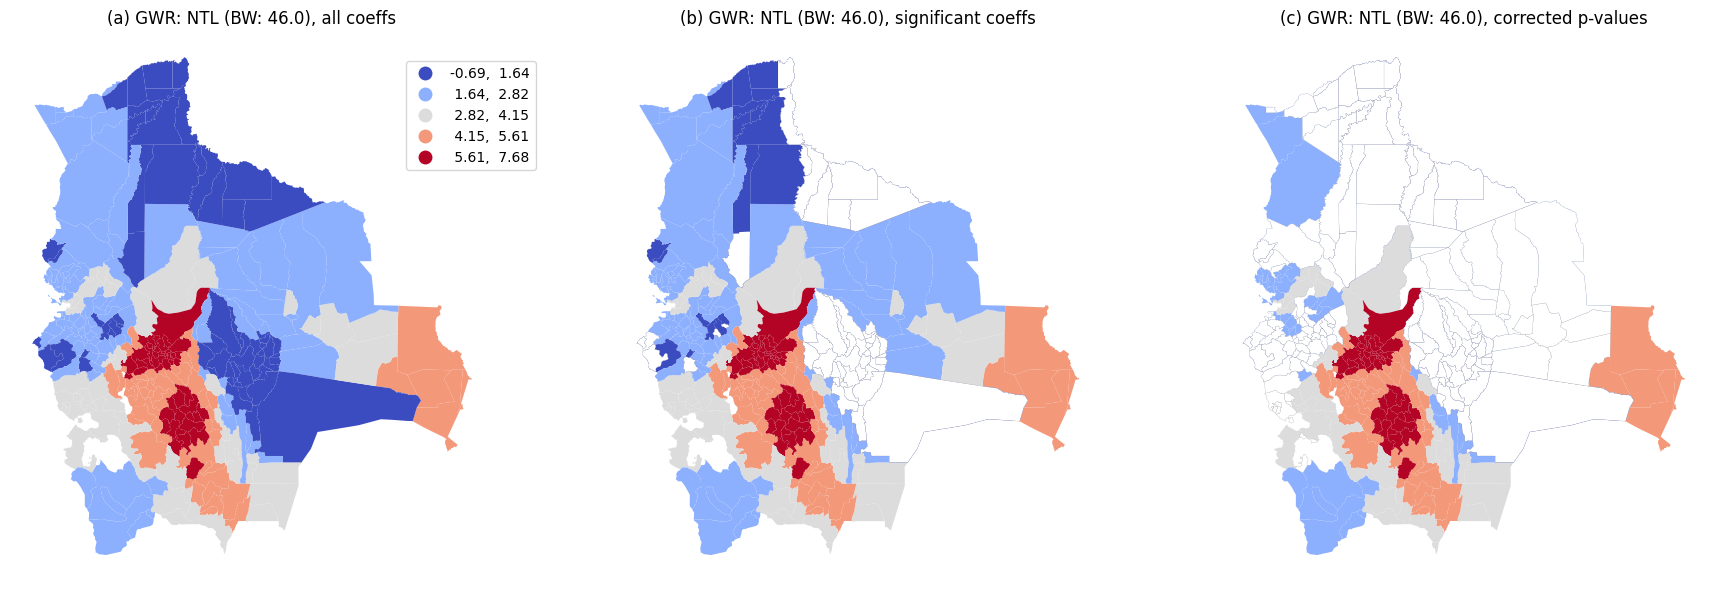

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

gdf.plot(column='gwr_slope1', cmap='coolwarm', linewidth=0.01, scheme='FisherJenks', k=5,
         legend=True, legend_kwds={'bbox_to_anchor': (1.10, 0.96)}, ax=axes[0])
axes[0].set_title(f'(a) GWR: NTL (BW: {gwr_bw}), all coeffs', fontsize=12)
axes[0].axis("off")

gdf.plot(column='gwr_slope1', cmap='coolwarm', linewidth=0.05, scheme='FisherJenks', k=5,
         legend=False, ax=axes[1])
gdf[gwr_filtered_t1[:, 1] == 0].plot(color='white', linewidth=0.05, edgecolor='black', ax=axes[1])
axes[1].set_title(f'(b) GWR: NTL (BW: {gwr_bw}), significant coeffs', fontsize=12)
axes[1].axis("off")

gdf.plot(column='gwr_slope1', cmap='coolwarm', linewidth=0.05, scheme='FisherJenks', k=5,
         legend=False, ax=axes[2])
gdf[gwr_filtered_tc1[:, 1] == 0].plot(color='white', linewidth=0.05, edgecolor='black', ax=axes[2])
axes[2].set_title(f'(c) GWR: NTL (BW: {gwr_bw}), corrected p-values', fontsize=12)
axes[2].axis("off")

plt.tight_layout()
plt.show()

## MGWR analysis

In [16]:
Zy = (y - y.mean(axis=0)) / y.std(axis=0)
ZX = (X - X.mean(axis=0)) / X.std(axis=0)

In [17]:
mgwr_selector = Sel_BW(coords, Zy, ZX, multi=True, spherical=True)
mgwr_bw = mgwr_selector.search(criterion='AICc')
mgwr_bw

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

array([44., 44.])

In [18]:
mgwr_results = MGWR(coords, Zy, ZX, mgwr_selector).fit()
mgwr_results.summary()

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Model type                                                         Gaussian
Number of observations:                                                 339
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            223.555
Log-likelihood:                                                    -410.450
AIC:                                                                824.900
AICc:                                                               826.972
BIC:                                                              -1739.807
R2:                                                                   0.341
Adj. R2:                                                              0.339

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [19]:
mgwr_bw_ci = mgwr_results.get_bws_intervals(mgwr_selector)
print(mgwr_bw_ci)

[(np.float64(44.0), np.float64(52.0)), (np.float64(44.0), np.float64(69.0))]


In [20]:
print('Mean R2 =', mgwr_results.R2)
print('AIC =',     mgwr_results.aic)
print('AICc =',    mgwr_results.aicc)

Mean R2 = 0.6237725845877591
AIC = 711.3822842941363
AICc = 722.6036114749796


In [21]:
gdf['mgwr_intercept'] = mgwr_results.params[:, 0]
gdf['mgwr_slope1'] = mgwr_results.params[:, 1]

mgwr_filtered_t1 = mgwr_results.filter_tvals(alpha=0.05)
mgwr_filtered_tc1 = mgwr_results.filter_tvals()

In [22]:
gdf.explore(
    column='mgwr_slope1',
    tooltip=[ADM1, ADM3, 'mgwr_slope1', INDICATOR4, INDICATOR1, INDICATOR3],
    k=5,
    scheme='FisherJenks',
    cmap='coolwarm',
    legend=True,
    tiles='CartoDB dark_matter',
    style_kwds=dict(color="gray", weight=0.4),
    legend_kwds=dict(colorbar=False)
)

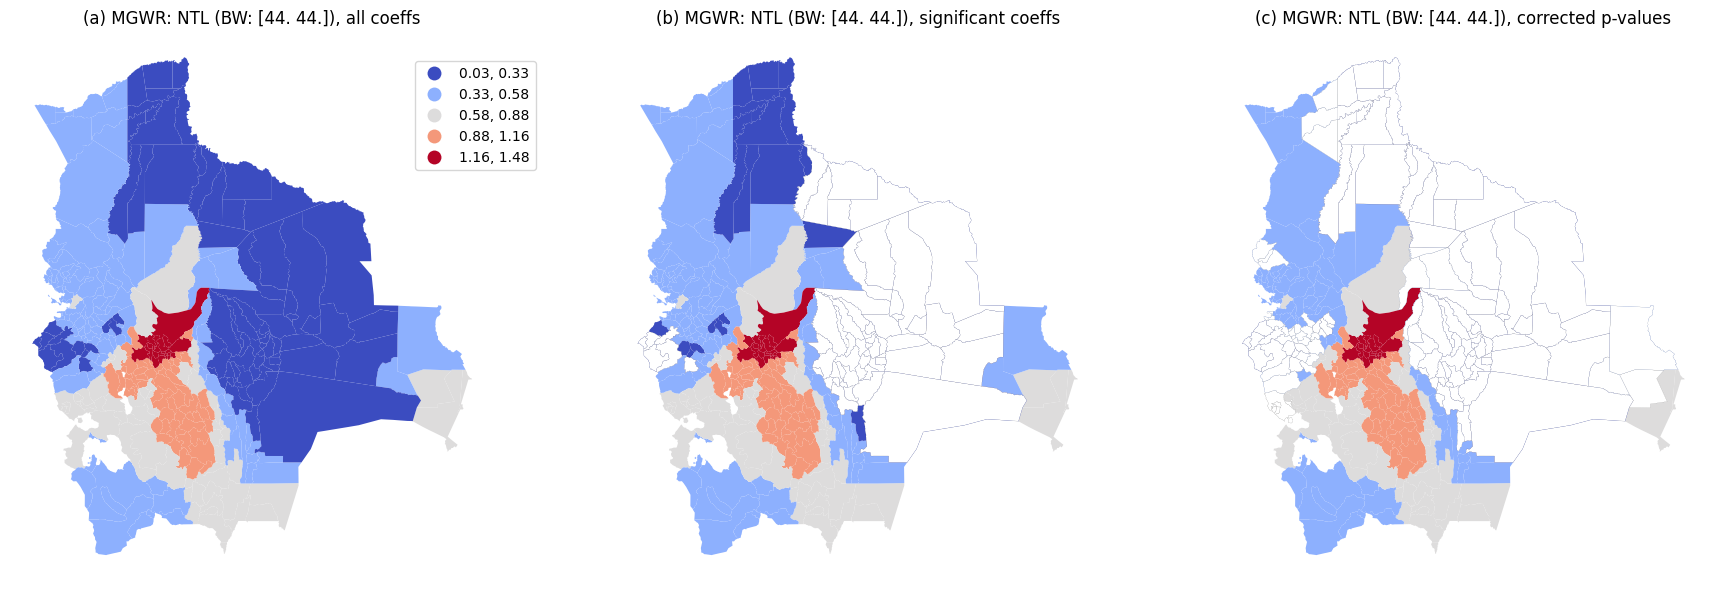

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

gdf.plot(column='mgwr_slope1', cmap='coolwarm', linewidth=0.01, scheme='FisherJenks', k=5,
         legend=True, legend_kwds={'bbox_to_anchor': (1.10, 0.96)}, ax=axes[0])
axes[0].set_title(f'(a) MGWR: NTL (BW: {mgwr_bw}), all coeffs', fontsize=12)
axes[0].axis("off")

gdf.plot(column='mgwr_slope1', cmap='coolwarm', linewidth=0.05, scheme='FisherJenks', k=5,
         legend=False, ax=axes[1])
gdf[mgwr_filtered_t1[:, 1] == 0].plot(color='white', linewidth=0.05, edgecolor='black', ax=axes[1])
axes[1].set_title(f'(b) MGWR: NTL (BW: {mgwr_bw}), significant coeffs', fontsize=12)
axes[1].axis("off")

gdf.plot(column='mgwr_slope1', cmap='coolwarm', linewidth=0.05, scheme='FisherJenks', k=5,
         legend=False, ax=axes[2])
gdf[mgwr_filtered_tc1[:, 1] == 0].plot(color='white', linewidth=0.05, edgecolor='black', ax=axes[2])
axes[2].set_title(f'(c) MGWR: NTL (BW: {mgwr_bw}), corrected p-values', fontsize=12)
axes[2].axis("off")

plt.tight_layout()
plt.show()